<a href="https://colab.research.google.com/github/madeseor/estructuras-de-bases-de-datos/blob/main/KDtree/KDtree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejercicio: implementar un arbol KD desde cero y compara fuerza bruta.



### Estructura de un Nodo KD (KDNode)

**En que momento el arbol-KD pasa a ser mas rapido que usar fuerza bruta?**

En nuestro codigo podemos evidenciar que el arbol-kd fue mucho mas rapido que la fuerza bruta segun nuestros tiempos de comparacion obtenidos:

**Arbol-kd:** 0.00019 segundos

**Fuerza bruta:** 0.00770 segundos


Para una dimension 2D, que es baja, y realizando multiples busquedas con muchos datos (10 mil en este caso) va a ser mucho mas rapido y por lo tanto eficiente usar el KD tree.

In [ ]:
import math # Importar math para funciones como sqrt (raíz cuadrada)

class KDNode:
    def __init__(self, point, axis, left=None, right=None):
        # El punto de datos que este nodo representa. Es una tupla o lista de coordenadas.
        self.point = point
        # El eje de división (dimensión) que este nodo utiliza para particionar el espacio.
        # en 2D: 0 para el eje X, 1 para el eje Y.
        self.axis = axis
        # Referencia al subárbol izquierdo, que contiene puntos con un valor menor
        # en el eje de división actual que el punto de este nodo.
        self.left = left
        # Referencia al subárbol derecho, que contiene puntos con un valor mayor o igual
        # en el eje de división actual que el punto de este nodo.
        self.right = right

    def __repr__(self):
        # Representación en cadena del nodo.
        return f"KDNode(point={self.point}, axis={self.axis})"

### Estructura del Árbol KD (KDTree)

In [ ]:
import math # Importar math para sqrt y funciones trigonométricas

class KDTree:
    # Radio de la Tierra en metros para cálculos de Haversine
    EARTH_RADIUS_METERS = 6371e3

    def __init__(self, k):
        # k: La dimensionalidad de los puntos que se almacenarán en el árbol (para (lat, lon)).
        self.k = k
        # La raíz del árbol KD. Inicialmente es None hasta que se inserta el primer punto.
        self.root = None

    def insert(self, point):
        # Método público para insertar un punto en el árbol.
        # Verifica que la dimensionalidad del punto sea correcta.
        if len(point) != self.k:
            raise ValueError(f"El punto debe tener {self.k} dimensiones.")
        # Llama a la función recursiva para insertar el punto, comenzando desde la raíz y profundidad 0.
        self.root = self._insert_recursive(self.root, point, depth=0)

    def _insert_recursive(self, node, point, depth):
        # Método auxiliar recursivo para insertar un punto.
        # node: El nodo actual en la recursion.
        # point: El punto a insertar.
        # depth: La profundidad actual en el árbol, que determina el eje de división.

        # Caso base: Si el nodo actual es None, hemos encontrado el lugar para insertar el nuevo punto.
        # Creamos un nuevo KDNode y establecemos su eje de división basado en la profundidad.
        if node is None:
            return KDNode(point, axis=depth % self.k)

        # Determina el eje de división para el nodo actual (0 para latitud, 1 para longitud).
        current_axis = node.axis

        # Compara el punto a insertar con el punto del nodo actual en el eje correspondiente.
        if point[current_axis] < node.point[current_axis]:
            # Si es menor, se inserta en el subárbol izquierdo.
            node.left = self._insert_recursive(node.left, point, depth + 1)
        else:
            # Si es mayor o igual, se inserta en el subárbol derecho.
            node.right = self._insert_recursive(node.right, point, depth + 1)
        return node

    def search(self, point):
        # Este es un método de búsqueda exacto para verificar si un punto existe en el árbol.
        # Para búsqueda de vecinos más cercanos (KNN) o búsqueda por rango, se necesitan algoritmos más complejos.
        return self._search_recursive(self.root, point, depth=0)

    def _search_recursive(self, node, point, depth):
        # Método auxiliar recursivo para la búsqueda exacta.

        # Caso base: Si el nodo es None, el punto no se encontró en este camino.
        if node is None:
            return False # No encontrado

        # Caso base: Si el punto del nodo actual es igual al punto buscado, lo hemos encontrado.
        if node.point == point:
            return True # Punto encontrado

        # Determina el eje de división del nodo actual.
        current_axis = node.axis

        # Continúa la búsqueda en el subárbol apropiado.
        if point[current_axis] < node.point[current_axis]:
            return self._search_recursive(node.left, point, depth + 1)
        else:
            return self._search_recursive(node.right, point, depth + 1)

    def build(self, points):
        # Método para construir el árbol a partir de una lista de puntos.
        # Itera sobre todos los puntos e los inserta uno por uno.
        for point in points:
            self.insert(point)

    def print_tree(self):
        # Método para imprimir una representación visual del árbol KD.
        print("\nVisualización del Árbol KD:")
        self._print_tree_recursive(self.root, depth=0)

    def _print_tree_recursive(self, node, depth):
        # Método auxiliar recursivo para imprimir el árbol.
        if node is not None:
            # Crea una sangría para mostrar la profundidad del nodo.
            indent = "  " * depth
            print(f"{indent}Node: {node.point} (Axis: {node.axis})")
            # Si tiene hijos, imprime las ramas izquierda y derecha.
            if node.left or node.right:
                if node.left:
                    print(f"{indent}  Left:")
                    self._print_tree_recursive(node.left, depth + 1)
                if node.right:
                    print(f"{indent}  Right:")
                    self._print_tree_recursive(node.right, depth + 1)

    @staticmethod
    def _haversine_distance(point1, point2):
        # Calcula la distancia Haversine entre dos puntos (latitud, longitud) en metros.
        # point1: (lat1, lon1), point2: (lat2, lon2)
        lat1, lon1 = math.radians(point1[0]), math.radians(point1[1])
        lat2, lon2 = math.radians(point2[0]), math.radians(point2[1])

        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

        return KDTree.EARTH_RADIUS_METERS * c

    def find_points_in_radius(self, query_point, radius_meters):
        # Método principal para encontrar todos los puntos dentro de un radio dado.
        # query_point: El punto central desde el cual se busca el radio (latitud, longitud).
        # radius_meters: El tamaño del radio de búsqueda en metros.

        found_points = [] # Lista para almacenar los puntos encontrados.

        # Calcular el radio angular aproximado en grados para la poda.
        # Esto crea un 'bounding box' aproximado para el pruning.
        # La variación en longitud depende de la latitud.
        query_lat_rad = math.radians(query_point[0])
        angular_radius_lat = math.degrees(radius_meters / self.EARTH_RADIUS_METERS) # Radio en grados de latitud
        # Radio en grados de longitud, ajustado por el coseno de la latitud para reflejar la convergencia de meridianos
        angular_radius_lon = math.degrees(radius_meters / (self.EARTH_RADIUS_METERS * math.cos(query_lat_rad)))

        self._find_points_in_radius_recursive(self.root, query_point, radius_meters, 0, found_points, angular_radius_lat, angular_radius_lon)
        return found_points

    def _find_points_in_radius_recursive(self, node, query_point, radius_meters, depth, found_points, angular_radius_lat, angular_radius_lon):
        # Método auxiliar recursivo para la búsqueda de puntos en un radio.

        if node is None:
            return

        # 1. Verificar si el punto del nodo actual está dentro del radio de la consulta usando Haversine.
        distance_to_node = self._haversine_distance(node.point, query_point)
        if distance_to_node <= radius_meters:
            found_points.append(node.point)

        # 2. Determinar el eje de división para el nodo actual.
        current_axis = node.axis # 0 para latitud, 1 para longitud

        # 3. Decidir qué subárboles explorar (pruning o poda) usando el radio angular.
        # El rango angular para la poda es diferente para latitud (eje 0) y longitud (eje 1).
        angular_bound = angular_radius_lat if current_axis == 0 else angular_radius_lon

        # Explorar el subárbol izquierdo si la esfera de búsqueda puede intersectar este lado.
        # Comprueba si el rango mínimo de la consulta (query_point - angular_bound) cruza el plano de división del nodo.
        if (query_point[current_axis] - angular_bound) < node.point[current_axis]:
            self._find_points_in_radius_recursive(node.left, query_point, radius_meters, depth + 1, found_points, angular_radius_lat, angular_radius_lon)

        # Explorar el subárbol derecho si la esfera de búsqueda puede intersectar este lado.
        # Comprueba si el rango máximo de la consulta (query_point + angular_bound) cruza el plano de división del nodo.
        if (query_point[current_axis] + angular_bound) > node.point[current_axis]:
             self._find_points_in_radius_recursive(node.right, query_point, radius_meters, depth + 1, found_points, angular_radius_lat, angular_radius_lon)

### 1. Generación de Datos de Puntos de Entrega

In [ ]:
import random
import time

n_points = 10000 # Número de puntos de entrega a generar
# Rango de coordenadas latitud y longitud para simular Buenos Aires - Argentina
# Zona grade, lo cual hara que al generar los vecinos tiendan a ser mas pocos.
lat_min, lat_max = -34.7, -34.5
lon_min, lon_max = -58.6, -58.3
k_dim = 2       # Dimensionalidad de los puntos (para (latitud, longitud))

#Generar 10,000 Puntos de Entrega Aleatorios
print(f"Generar {n_points} puntos de entrega aleatorios (Latitud, Longitud)")
delivery_points = []
for _ in range(n_points):
    lat = random.uniform(lat_min, lat_max)
    lon = random.uniform(lon_min, lon_max)
    delivery_points.append((lat, lon))

print(f"Se generaron {len(delivery_points)} puntos de entrega.")

Generar 10000 puntos de entrega aleatorios (Latitud, Longitud)
Se generaron 10000 puntos de entrega.


### 2. Construcción del Árbol KD con los Puntos de Entrega

In [ ]:
#Construir el Árbol KD
print("Construyendo el Árbol KD con los puntos de entrega:")
kd_tree = KDTree(k_dim)
kd_tree.build(delivery_points)
print("Árbol KD construido exitosamente.")

Construyendo el Árbol KD con los puntos de entrega:
Árbol KD construido exitosamente.


### 3. Búsqueda de Puntos en un Radio (Usando KD-Tree)

In [ ]:
#Definir el Punto de Consulta y el Radio
# Generar un punto de consulta aleatorio dentro del rango de nuestros delivery_points
query_point = (random.uniform(lat_min, lat_max), random.uniform(lon_min, lon_max)) # Un punto aleatorio para consultar
radius_meters = 500 # Radio de búsqueda en metros
print(f"\nPunto de consulta: {query_point}, Radio: {radius_meters} metros")

#Búsqueda usando KD
print("Realizando búsqueda por radio con KD-Tree")
start_time_kd = time.time()
points_in_radius_kd = kd_tree.find_points_in_radius(query_point, radius_meters)
end_time_kd = time.time()

print(f"Puntos encontrados con KD-Tree: {len(points_in_radius_kd)}")
print(f"Tiempo de ejecución (KD-Tree): {end_time_kd - start_time_kd:.6f} segundos")
# Muestra los primeros 5 puntos si hay muchos, o todos si son pocos.
if len(points_in_radius_kd) > 5:
    print("Primeros 5 puntos encontrados (KD-Tree):", points_in_radius_kd[:5], ".")
else:
    print("Puntos encontrados (KD-Tree):", points_in_radius_kd)


Punto de consulta: (-34.532921938400186, -58.59613774780947), Radio: 500 metros
Realizando búsqueda por radio con KD-Tree
Puntos encontrados con KD-Tree: 13
Tiempo de ejecución (KD-Tree): 0.000190 segundos
Primeros 5 puntos encontrados (KD-Tree): [(-34.53635988994868, -58.59918486070546), (-34.530623333811924, -58.59883480310691), (-34.53315789099494, -58.59689928397677), (-34.53700874128816, -58.596284843848906), (-34.534773119972925, -58.59796235440326)] .


### 4. Búsqueda de Puntos en un Radio (Fuerza Bruta para Comparación)

In [ ]:
# --- Función Auxiliar para Distancia Haversine (para fuerza bruta) ---
def haversine_distance(point1, point2):
    # Reutilizamos el método estático del KDTree para la consistencia
    return KDTree._haversine_distance(point1, point2)

# --- Búsqueda por Fuerza Bruta ---
print("\nRealizando búsqueda por radio con Fuerza Bruta:")
start_time_brute = time.time()
points_in_radius_brute = []
for p in delivery_points:
    if haversine_distance(p, query_point) <= radius_meters:
        points_in_radius_brute.append(p)
end_time_brute = time.time()

print(f"Puntos encontrados con Fuerza Bruta: {len(points_in_radius_brute)}")
print(f"Tiempo de ejecución (Fuerza Bruta): {end_time_brute - start_time_brute:.6f} segundos")
# Muestra los primeros 5 puntos si hay muchos, o todos si son pocos.
if len(points_in_radius_brute) > 5:
    print("Primeros 5 puntos encontrados (Fuerza Bruta):", points_in_radius_brute[:5], "...")
else:
    print("Puntos encontrados (Fuerza Bruta):", points_in_radius_brute)

#Verificación de Resultados (Opcional)
print(f"Coinciden los resultados: {set(points_in_radius_kd) == set(points_in_radius_brute)}")


Realizando búsqueda por radio con Fuerza Bruta:
Puntos encontrados con Fuerza Bruta: 13
Tiempo de ejecución (Fuerza Bruta): 0.007779 segundos
Primeros 5 puntos encontrados (Fuerza Bruta): [(-34.53315789099494, -58.59689928397677), (-34.53618548268519, -58.59288805956968), (-34.529332444662685, -58.59386429954988), (-34.53700874128816, -58.596284843848906), (-34.534773119972925, -58.59796235440326)] ...
Coinciden los resultados: True


### 5. Verificación Visual de la Búsqueda por Radio

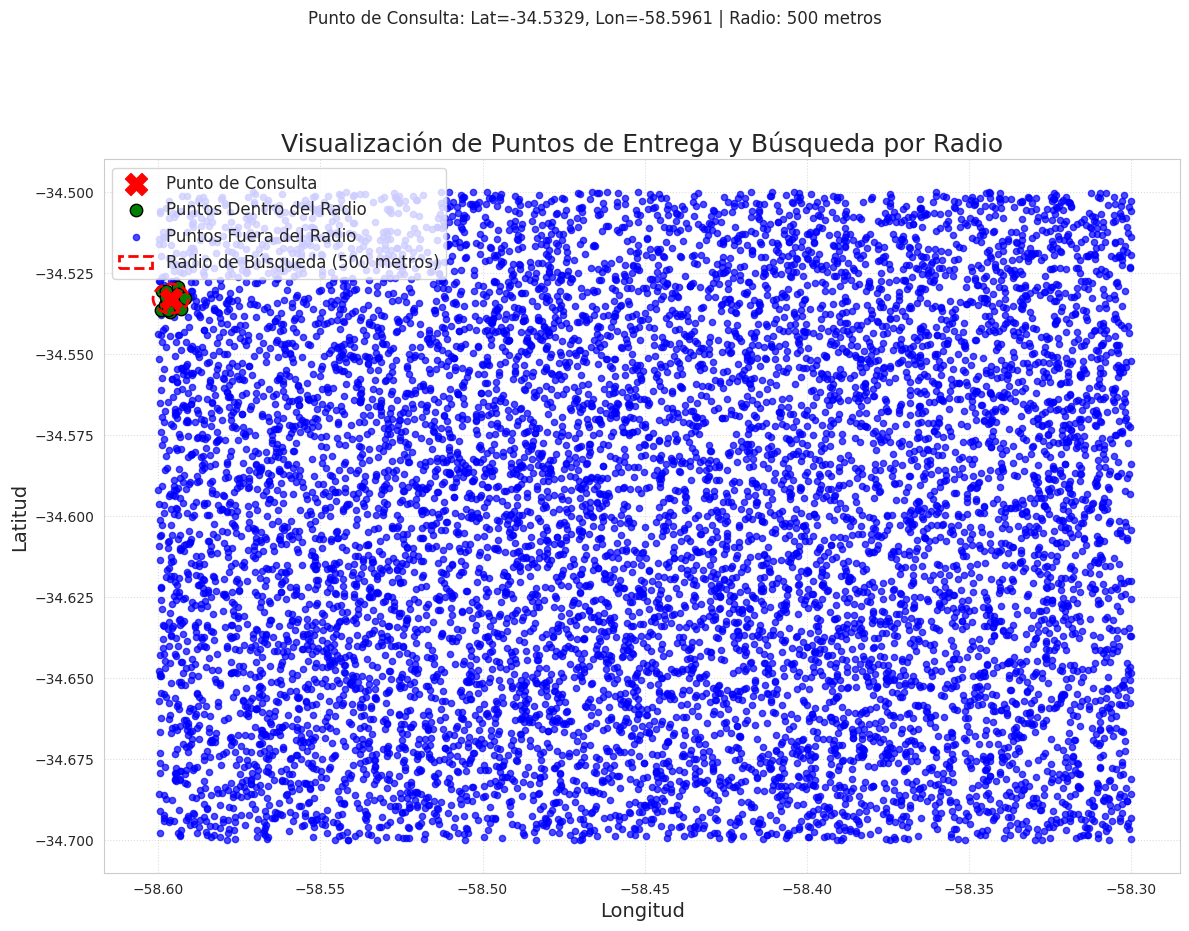

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import numpy as np

# Recalcular radios angulares para la visualización, ya que se necesitan en grados
# para dibujar la elipse que representa el área de búsqueda.
# query_point, radius_meters, KDTree.EARTH_RADIUS_METERS ya están definidos y disponibles.
query_lat_rad = math.radians(query_point[0])
angular_radius_lat_deg = math.degrees(radius_meters / KDTree.EARTH_RADIUS_METERS)
angular_radius_lon_deg = math.degrees(radius_meters / (KDTree.EARTH_RADIUS_METERS * math.cos(query_lat_rad)))

plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

# Convertir listas de tuplas a arrays de NumPy para facilitar el ploteo
delivery_points_np = np.array(delivery_points)
points_in_radius_np = np.array(points_in_radius_kd)

# 1. Plotear el punto de consulta (rojo, cruz grande)
plt.scatter(query_point[1], query_point[0], color='red', marker='X', s=250, label='Punto de Consulta', zorder=5)

# 2. Plotear los puntos encontrados dentro del radio (verde, más grandes)
if len(points_in_radius_np) > 0:
    plt.scatter(points_in_radius_np[:, 1], points_in_radius_np[:, 0], s=80, color='green', label='Puntos Dentro del Radio', zorder=4, edgecolor='black')

# 3. Plotear los puntos fuera del radio (azul, pequeños)
# Calculamos los puntos que no están en points_in_radius_kd
# Convertimos a conjunto para una comparación eficiente, luego de vuelta a lista para NumPy
set_points_in_radius = set(points_in_radius_kd)
points_outside_radius = [p for p in delivery_points if p not in set_points_in_radius]
points_outside_radius_np = np.array(points_outside_radius)
if len(points_outside_radius_np) > 0:
    plt.scatter(points_outside_radius_np[:, 1], points_outside_radius_np[:, 0], s=20, color='blue', alpha=0.7, label='Puntos Fuera del Radio', zorder=3)

# 4. Dibujar el círculo de radio alrededor del punto de consulta
# Usamos una elipse para aproximar el círculo en coordenadas de lat/lon
# debido a la distorsión de la proyección. Los 'angular_radius_lon_deg' y 'angular_radius_lat_deg'
# ya están escalados correctamente para el grado de latitud de la consulta.
circle_patch = Ellipse((query_point[1], query_point[0]),
                       width=2 * angular_radius_lon_deg, # 2 * radio angular en longitud
                       height=2 * angular_radius_lat_deg, # 2 * radio angular en latitud
                       angle=0, color='red', fill=False, linestyle='--', linewidth=2, zorder=6,
                       label=f'Radio de Búsqueda ({radius_meters} metros)')
plt.gca().add_patch(circle_patch)

# Configuración de la gráfica
plt.title('Visualización de Puntos de Entrega y Búsqueda por Radio', fontsize=18)
plt.suptitle(f'Punto de Consulta: Lat={query_point[0]:.4f}, Lon={query_point[1]:.4f} | Radio: {radius_meters} metros', fontsize=12)
plt.xlabel('Longitud', fontsize=14)
plt.ylabel('Latitud', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.gca().set_aspect('equal', adjustable='box') # Mantiene la proporción para que el círculo se vea bien
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el supertítulo no se solape
plt.show()

### 6. Verificación Visual Detallada del Radio de Búsqueda

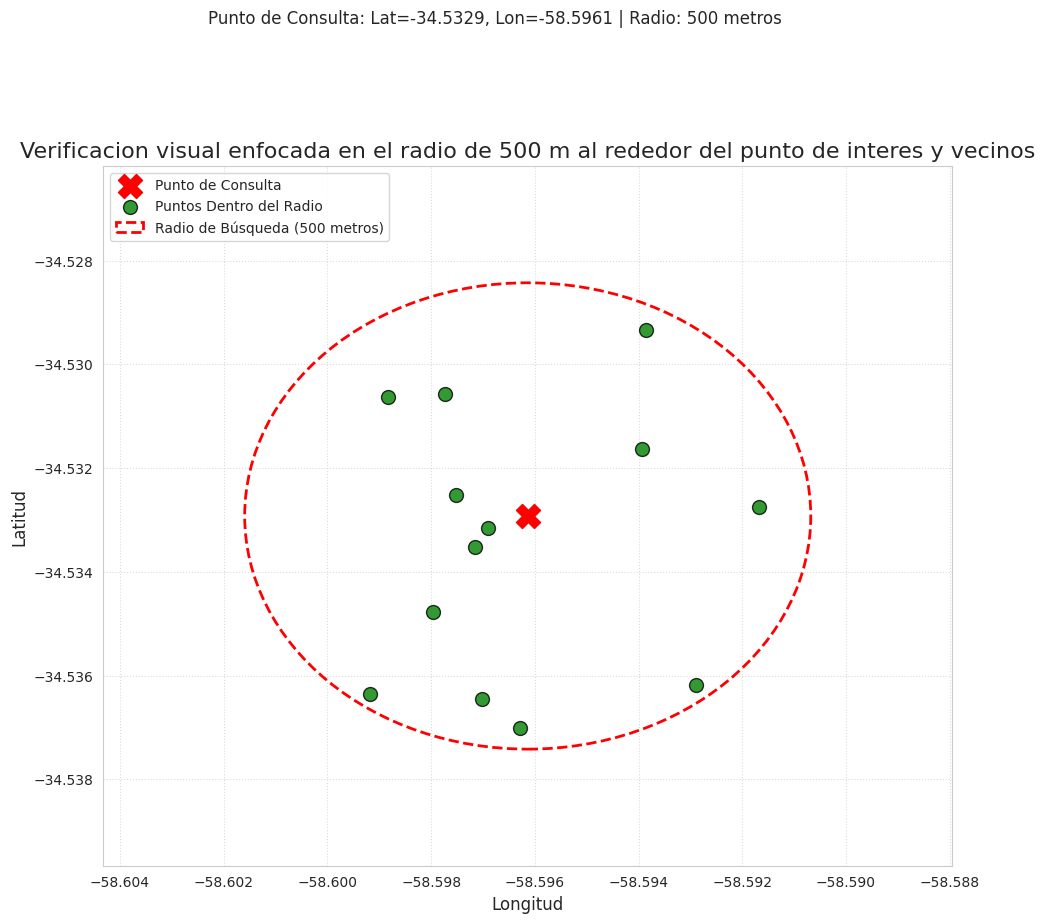

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
import numpy as np

# Los radios angulares ya están calculados y disponibles de la celda anterior:
# query_point, radius_meters, angular_radius_lat_deg, angular_radius_lon_deg

plt.figure(figsize=(10, 10))
sns.set_style("whitegrid")

# Convertir listas de tuplas a arrays de NumPy para facilitar el ploteo
points_in_radius_np = np.array(points_in_radius_kd)

# 1. Plotear el punto de consulta (rojo, cruz grande)
plt.scatter(query_point[1], query_point[0], color='red', marker='X', s=300, label='Punto de Consulta', zorder=5)

# 2. Plotear solo los puntos encontrados dentro del radio (verde, más grandes)
if len(points_in_radius_np) > 0:
    plt.scatter(points_in_radius_np[:, 1], points_in_radius_np[:, 0], s=100, color='green', label='Puntos Dentro del Radio', zorder=4, edgecolor='black', alpha=0.8)

# 3. Dibujar el círculo de radio alrededor del punto de consulta
circle_patch = Ellipse((query_point[1], query_point[0]),
                       width=2 * angular_radius_lon_deg,
                       height=2 * angular_radius_lat_deg,
                       angle=0, color='red', fill=False, linestyle='--', linewidth=2, zorder=6,
                       label=f'Radio de Búsqueda ({radius_meters} metros)')
plt.gca().add_patch(circle_patch)

# Configuración de la gráfica para un zoom más cercano
plt.title('Verificacion visual enfocada en el radio de 500 m al rededor del punto de interes y vecinos', fontsize=16)
plt.suptitle(f'Punto de Consulta: Lat={query_point[0]:.4f}, Lon={query_point[1]:.4f} | Radio: {radius_meters} metros', fontsize=12)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.gca().set_aspect('equal', adjustable='box') # Mantiene la proporción

# Establecer límites de los ejes para hacer un zoom alrededor del query_point y el radio
# Añadimos un pequeño margen para que el círculo no esté pegado al borde
margin_lat = angular_radius_lat_deg * 1.5 # 50% más grande que el radio para el margen
margin_lon = angular_radius_lon_deg * 1.5

plt.xlim(query_point[1] - margin_lon, query_point[1] + margin_lon)
plt.ylim(query_point[0] - margin_lat, query_point[0] + margin_lat)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el supertítulo no se solape
plt.show()